# Fase 3 — CNN mínima de depuración

El objetivo no es conseguir un buen modelo clínico. Queremos demostrar, paso a paso, que el circuito completo funciona: tensor → convoluciones → logit → pérdida → gradientes → actualización de pesos.

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn

from src.data import BreastDCEDataset, load_samples, split_by_patient_fold
from src.model import MinimalCNN, parameter_breakdown, trainable_parameter_count
from src.overfit_smoke import (
    OverfitConfig, run_overfit_experiment, select_balanced_patient_subset
)

DATA_ROOT = ROOT / 'breastdcedl'
REPORT_DIR = ROOT / 'reports' / 'phase3_minimal'
torch.manual_seed(42)
print('PyTorch:', torch.__version__)
print('Raíz:', ROOT)

Matplotlib is building the font cache; this may take a moment.


PyTorch: 2.11.0
Raíz: /Users/ruben/Desktop/4º INGENIERÍA MATEMÁTICA/APRENDIZAJE AUTOMATICO/CASO 1/CASO_ANALISIS_CANCER


## 1. Elegimos un subconjunto pequeño y equilibrado

Tomamos 24 pacientes distintas del entrenamiento interno: 12 con pCR=0 y 12 con pCR=1. No usamos validación ni test. Para esta prueba queremos memorizar deliberadamente, no medir generalización.

In [2]:
samples = load_samples(DATA_ROOT)
splits = split_by_patient_fold(samples, validation_fold=0)
subset = select_balanced_patient_subset(splits.train, sample_count=24, seed=42)
dataset = BreastDCEDataset(subset, DATA_ROOT)
example = dataset[0]

print('Pacientes únicas:', subset.patient_id.nunique())
print('Clases:', subset.pCR.value_counts().sort_index().to_dict())
print('Tensor de una muestra:', tuple(example['image'].shape))
print('Etiqueta:', float(example['target']))
print('Muestra:', example['sample_id'])

Pacientes únicas: 24
Clases: {0: 12, 1: 12}
Tensor de una muestra: (3, 256, 256)
Etiqueta: 0.0
Muestra: ACRIN-6698-641697_z019


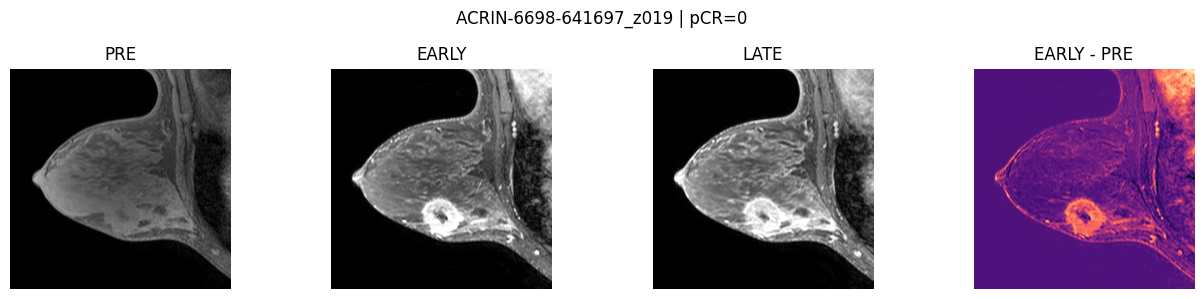

In [3]:
image = example['image']
enhancement = image[1] - image[0]
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for axis, channel, title in zip(axes[:3], image, ('PRE', 'EARLY', 'LATE')):
    axis.imshow(channel, cmap='gray', vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis('off')
axes[3].imshow(enhancement, cmap='magma')
axes[3].set_title('EARLY - PRE')
axes[3].axis('off')
plt.suptitle(f"{example['sample_id']} | pCR={int(example['target'])}")
plt.tight_layout()

## 2. Arquitectura mínima

Las convoluciones mantienen inicialmente la resolución porque usan kernel 3×3, stride 1 y padding 1. Cada pooling divide altura y anchura entre dos. `AdaptiveAvgPool2d(4,4)` resume cada uno de los 32 mapas en una cuadrícula 4×4 antes de la clasificación.

In [4]:
torch.manual_seed(42)
model = MinimalCNN()
shape_table = pd.DataFrame([
    {'operación': step.operation, 'forma': str(step.shape)}
    for step in model.trace_shapes(batch_size=2)
])
parameter_table = pd.DataFrame(parameter_breakdown(model))
display(shape_table)
display(parameter_table)
print('Parámetros entrenables:', f'{trainable_parameter_count(model):,}')

,operación,forma
0,entrada,"(2, 3, 256, 256)"
1,conv1 3→8,"(2, 8, 256, 256)"
2,relu1,"(2, 8, 256, 256)"
3,pool1,"(2, 8, 128, 128)"
4,conv2 8→16,"(2, 16, 128, 128)"
5,relu2,"(2, 16, 128, 128)"
6,pool2,"(2, 16, 64, 64)"
7,conv3 16→32,"(2, 32, 64, 64)"
8,relu3,"(2, 32, 64, 64)"
9,pool3,"(2, 32, 32, 32)"


,name,shape,parameters
0,conv1.weight,"(8, 3, 3, 3)",216
1,conv1.bias,"(8,)",8
2,conv2.weight,"(16, 8, 3, 3)",1152
3,conv2.bias,"(16,)",16
4,conv3.weight,"(32, 16, 3, 3)",4608
5,conv3.bias,"(32,)",32
6,classifier.weight,"(1, 512)",512
7,classifier.bias,"(1,)",1


Parámetros entrenables: 6,545


### Cálculo de parámetros

- Conv1: `8 × (3 × 3 × 3 + 1) = 224`
- Conv2: `16 × (8 × 3 × 3 + 1) = 1.168`
- Conv3: `32 × (16 × 3 × 3 + 1) = 4.640`
- Lineal: `1 × (512 + 1) = 513`
- Total: `6.545` parámetros entrenables

## 3. Forward: de imágenes a logits

El modelo no devuelve directamente probabilidades. Devuelve un logit por muestra. Aplicamos sigmoide únicamente cuando queremos interpretar ese número como probabilidad.

In [5]:
batch_images = torch.stack([dataset[i]['image'] for i in range(4)])
batch_targets = torch.stack([dataset[i]['target'] for i in range(4)])
logits = model(batch_images)
probabilities = torch.sigmoid(logits)

print('Batch de entrada:', tuple(batch_images.shape))
print('Logits:', logits.detach())
print('Probabilidades:', probabilities.detach())
print('Etiquetas:', batch_targets)

Batch de entrada: (4, 3, 256, 256)
Logits: tensor([0.0012, 0.0528, 0.0073, 0.0521])
Probabilidades: tensor([0.5003, 0.5132, 0.5018, 0.5130])
Etiquetas: tensor([0., 1., 0., 1.])


## 4. Backward: el error llega hasta los kernels

`BCEWithLogitsLoss` compara logits y etiquetas. `loss.backward()` calcula el gradiente de cada parámetro. El optimizador usará esos gradientes para modificar los kernels.

In [6]:
criterion = nn.BCEWithLogitsLoss()
model.zero_grad(set_to_none=True)
loss = criterion(model(batch_images), batch_targets)
loss.backward()
gradient_rows = [
    {'parámetro': name, 'norma_gradiente': float(parameter.grad.norm())}
    for name, parameter in model.named_parameters()
]
print('Loss:', float(loss))
display(pd.DataFrame(gradient_rows))

Loss: 0.6812636852264404


/var/folders/ts/818xf2p14pbgs4y569ly36980000gn/T/ipykernel_9901/103735230.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print('Loss:', float(loss))


,parámetro,norma_gradiente
0,conv1.weight,0.085192
1,conv1.bias,0.047840
2,conv2.weight,0.103281
3,conv2.bias,0.052280
4,conv3.weight,0.111835
5,conv3.bias,0.048278
6,classifier.weight,0.151412
7,classifier.bias,0.007088


## 5. Prueba de memorización

La prueba completa se ejecuta con `python -m src.overfit_smoke`. Debe alcanzar 100% en las 24 muestras. Esto solo demuestra que el pipeline puede aprender; no demuestra generalización.

In [7]:
RUN_TRAINING = False  # Cambiar a True para repetir el entrenamiento
report_path = REPORT_DIR / 'report.json'
if RUN_TRAINING or not report_path.exists():
    report = run_overfit_experiment(
        DATA_ROOT, REPORT_DIR, OverfitConfig(samples=24, epochs=150, seed=42)
    )
else:
    report = json.loads(report_path.read_text(encoding='utf-8'))

print('Éxito:', report['success'])
print('Épocas:', report['epochs_completed'])
print('Accuracy final:', report['final_accuracy'])
print('Loss final:', round(report['final_loss'], 6))
print('Tiempo:', round(report['elapsed_seconds'], 2), 's')

Éxito: True
Épocas: 40
Accuracy final: 1.0
Loss final: 0.050218
Tiempo: 4.46 s


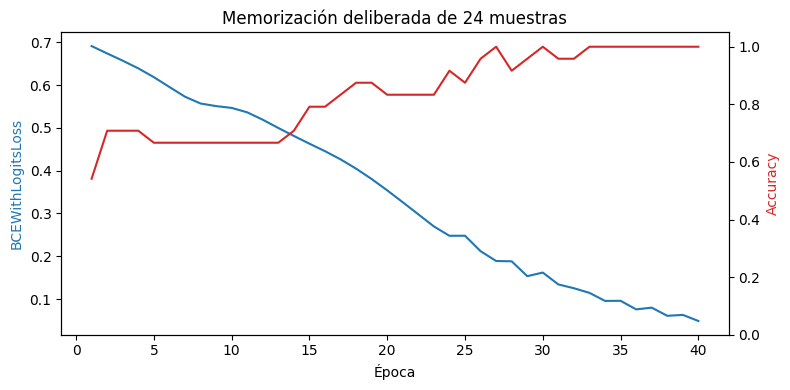

In [8]:
history = pd.DataFrame(report['history'])
fig, loss_axis = plt.subplots(figsize=(8, 4))
accuracy_axis = loss_axis.twinx()
loss_axis.plot(history.epoch, history.loss, color='tab:blue', label='Loss')
accuracy_axis.plot(history.epoch, history.accuracy, color='tab:red', label='Accuracy')
loss_axis.set_xlabel('Época')
loss_axis.set_ylabel('BCEWithLogitsLoss', color='tab:blue')
accuracy_axis.set_ylabel('Accuracy', color='tab:red')
accuracy_axis.set_ylim(0, 1.05)
plt.title('Memorización deliberada de 24 muestras')
plt.tight_layout()

## Conclusión

La red recibe `[B,3,256,256]`, produce un logit por muestra, todos los parámetros reciben gradiente y el optimizador logra memorizar el subconjunto. La tubería está preparada para diseñar una arquitectura base orientada a generalización.